**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
**Proyecto: Análisis Exploratorio y Técnicas de Preprocesamiento de Datos**  
*Caso de Estudio: Base de Datos de Cáncer de Mama de Wisconsin (WBCD)*

---

## 1. Introducción

El cáncer de mama es una de las enfermedades más estudiadas en el área de la salud. En los hospitales, la **Biopsia por Aspiración con Aguja Fina (BAAF)** es un estudio médico rápido y poco invasivo que extrae células de un nódulo mamario para revisarlas bajo el microscopio (Wolberg & Mangasarian, 1990).

La base de datos **Wisconsin Breast Cancer Database (WBCD)** fue obtenida por el **Dr. William H. Wolberg** en los Hospitales de la Universidad de Wisconsin, Madison (Wolberg & Mangasarian, 1990) y compartida en el repositorio de Machine Learning de la Universidad de California en Irvine (Aha & Wolberg, 1992). Los datos contienen evaluaciones de células en una escala del 1 al 10 (donde 1 indica valores normales y 10 anomalías severas), junto con el diagnóstico del paciente: **Benigno (clase 2)** o **Maligno (clase 4)**.

### Objetivos del Proyecto:
1. **Análisis Exploratorio de Datos (EDA):** Revisar los datos, calcular estadísticas descriptivas (Tabla 1) y analizar las distribuciones y correlaciones con gráficas (Figura 1 y Figura 2).
2. **Técnica 1 - Limpieza de Datos:** Identificar los valores faltantes (marcados con `?` en la columna *Bare Nuclei*) y rellenarlos con la mediana según el diagnóstico (Figura 3).
3. **Técnica 2 - Extracción de Características:** Crear nuevas variables combinadas (índices citológicos) que ayuden a separar mejor las muestras benignas de las malignas (Figura 4).
4. **Técnica 3 - Aumento de Datos:** Balancear la cantidad de muestras malignas frente a las benignas utilizando la técnica **SMOTE** (Chawla et al., 2002) (Figura 5).
5. **Técnica 4 - Reducción de Dimensionalidad:** Reducir las 9 variables originales a 2 Componentes Principales con **PCA** (Jolliffe & Cadima, 2016) para visualizar los datos en dos dimensiones (Figura 6).
6. **Comparaciones Antes vs Después:** Graficar el estado de los datos antes y después de aplicar cada una de las técnicas de procesamiento.

---

## 2. Preparación y Librerías

Importamos las librerías necesarias de Python para trabajar con tablas (`pandas`, `numpy`), hacer gráficas (`matplotlib`, `seaborn`), aplicar transformaciones (`scikit-learn`) y generar datos sintéticos (`imbalanced-learn`).

In [1]:
# Importar librerias principales
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas para normalizar, PCA y SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# Ver versiones instaladas
print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", __import__("matplotlib").__version__)
print("seaborn   ", sns.__version__)
print("sklearn   ", __import__("sklearn").__version__)
print("imblearn  ", __import__("imblearn").__version__)

numpy      2.3.3
pandas     2.3.3
matplotlib 3.10.7
seaborn    0.13.2
sklearn    1.7.2
imblearn   0.14.2


Definimos los colores oficiales del curso para que todas las gráficas mantengan el mismo estilo visual.

In [2]:
# Colores del curso
AZUL_OSCURO = "#112057"
AZUL        = "#7697CD"
AZUL_CLARO  = "#BFD5EA"
ROJO        = "#C02B2B"

# Estilo de las graficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlecolor"] = AZUL_OSCURO
plt.rcParams["axes.titleweight"] = "bold"

# Formato para ver numeros con 2 decimales
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

---

## 3. Carga y Estructura del Dataset

### Diccionario de Variables (Wolberg & Mangasarian, 1990; Aha & Wolberg, 1992):
El dataset cuenta con 11 columnas con valores medidos del 1 al 10 (excepto el código y la clase):

1. **`Sample_Code_Number`**: Código identificador de la muestra clínica.
2. **`Clump_Thickness`** (Grosor celular): Evalúa si las células están en capas delgadas ($1$) o en cúmulos gruesos ($10$).
3. **`Uniformity_Cell_Size`** (Uniformidad de tamaño): Evalúa si las células tienen tamaño similar ($1$) o disparejo ($10$).
4. **`Uniformity_Cell_Shape`** (Uniformidad de forma): Evalúa si las células tienen forma normal ($1$) o formas deformes e irregulares ($10$).
5. **`Marginal_Adhesion`** (Adhesión marginal): Qué tan unidas están las células entre sí; las células cancerosas suelen despegarse ($10$).
6. **`Single_Epithelial_Cell_Size`** (Tamaño de célula epitelial): Tamaño de una célula individual agrandada.
7. **`Bare_Nuclei`** (Núcleos desnudos): Núcleos sin membrana alrededor; muy común en cáncer.
8. **`Bland_Chromatin`** (Cromatina suave): Textura del núcleo; cromatina fina ($1$) vs grumos densos ($10$).
9. **`Normal_Nucleoli`** (Nucléolos normales): Tamaño y visibilidad de los nucléolos en el núcleo.
10. **`Mitoses`** (Actividad mitótica): Cantidad de células que se observan dividiéndose.
11. **`Class`** (Diagnóstico final): **`2 = Benigno`** (normal) o **`4 = Maligno`** (canceroso).

In [3]:
# Nombres de las columnas del dataset
columnas = [
    "Sample_Code_Number",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

# Nombre del archivo de datos
archivo_datos = "breast-cancer-wisconsin.data"
if not os.path.exists(archivo_datos):
    archivo_datos = r"C:\Users\ruben\OneDrive\Desktop\Notebook Preprocesamiento\breast-cancer-wisconsin.data"

# Leer el archivo usando pandas
# names agrega los nombres de las columnas
# header=None indica que el archivo no tiene encabezados
df = pd.read_csv(
    archivo_datos,
    names=columnas,
    header=None
)

# Mostrar cuántos registros y columnas tiene el dataset
print("Número de registros:", len(df))
print("Número de atributos:", len(df.columns))

# Comprobar si el dataset tiene más de 500 registros
if len(df) >= 500:
    print("Cumple con el volumen suficiente: Sí")
else:
    print("Cumple con el volumen suficiente: No")

# Mostrar los primeros 5 registros
# Esto permite revisar cómo están organizados los datos
df.head(5)

Número de registros: 699
Número de atributos: 11
Cumple con el volumen suficiente: Sí


,Sample_Code_Number,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


---

## 4. Análisis Exploratorio de Datos (EDA)

Revisamos los tipos de datos de cada columna y si existen registros con valores faltantes o caracteres especiales.

In [4]:
# Mostrar tipos de datos
print("Tipos de datos en cada columna:")
print(df.dtypes)

# Contar valores faltantes marcados con '?'
print("\nValores faltantes con '?':", (df["Bare_Nuclei"] == "?").sum())

# Contar cuántos casos benignos y malignos hay
print("\nDistribución por diagnóstico (2=Benigno, 4=Maligno):")
print(df["Class"].value_counts())

Tipos de datos en cada columna:
Sample_Code_Number              int64
Clump_Thickness                 int64
Uniformity_Cell_Size            int64
Uniformity_Cell_Shape           int64
Marginal_Adhesion               int64
Single_Epithelial_Cell_Size     int64
Bare_Nuclei                    object
Bland_Chromatin                 int64
Normal_Nucleoli                 int64
Mitoses                         int64
Class                           int64
dtype: object

Valores faltantes con '?': 16

Distribución por diagnóstico (2=Benigno, 4=Maligno):
Class
2    458
4    241
Name: count, dtype: int64


### 4.1. Análisis Univariado y Estadísticos Descriptivos

Convertimos temporalmente los valores `'?'` a valores numéricos (`NaN`) para calcular la tabla de estadísticas descriptivas (media, desviación estándar, mínimos, cuartiles y máximos) de las 9 variables celulares.

In [5]:
# Lista de variables celulares
variables = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

# Copia para el análisis
df_eda = df.copy()

# Convertir Bare_Nuclei a números
df_eda["Bare_Nuclei"] = pd.to_numeric(df_eda["Bare_Nuclei"], errors="coerce")

# Agregar nombre del diagnóstico
df_eda["Diagnostico"] = df_eda["Class"].replace({2: "Benigno", 4: "Maligno"})

# Calcular tabla de estadísticos descriptivos
stats = df_eda[variables].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

# Mostrar la tabla redondeada a 2 decimales
print("Tabla 1. Estadísticos descriptivos:")
stats.round(2)

Tabla 1. Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
Clump_Thickness,699.00,4.42,2.82,1.00,2.00,4.00,6.00,10.00
Uniformity_Cell_Size,699.00,3.13,3.05,1.00,1.00,1.00,5.00,10.00
Uniformity_Cell_Shape,699.00,3.21,2.97,1.00,1.00,1.00,5.00,10.00
Marginal_Adhesion,699.00,2.81,2.86,1.00,1.00,1.00,4.00,10.00
Single_Epithelial_Cell_Size,699.00,3.22,2.21,1.00,2.00,2.00,4.00,10.00
Bare_Nuclei,683.00,3.54,3.64,1.00,1.00,1.00,6.00,10.00
Bland_Chromatin,699.00,3.44,2.44,1.00,2.00,3.00,5.00,10.00
Normal_Nucleoli,699.00,2.87,3.05,1.00,1.00,1.00,4.00,10.00
Mitoses,699.00,1.59,1.72,1.00,1.00,1.00,1.00,10.00


Generamos la **Figura 1** para comparar cómo se distribuyen dos variables importantes entre pacientes benignos y malignos:
- **Figura 1A:** Grosor del grupo celular (*Clump Thickness*).
- **Figura 1B:** Uniformidad del tamaño celular (*Uniformity of Cell Size*).

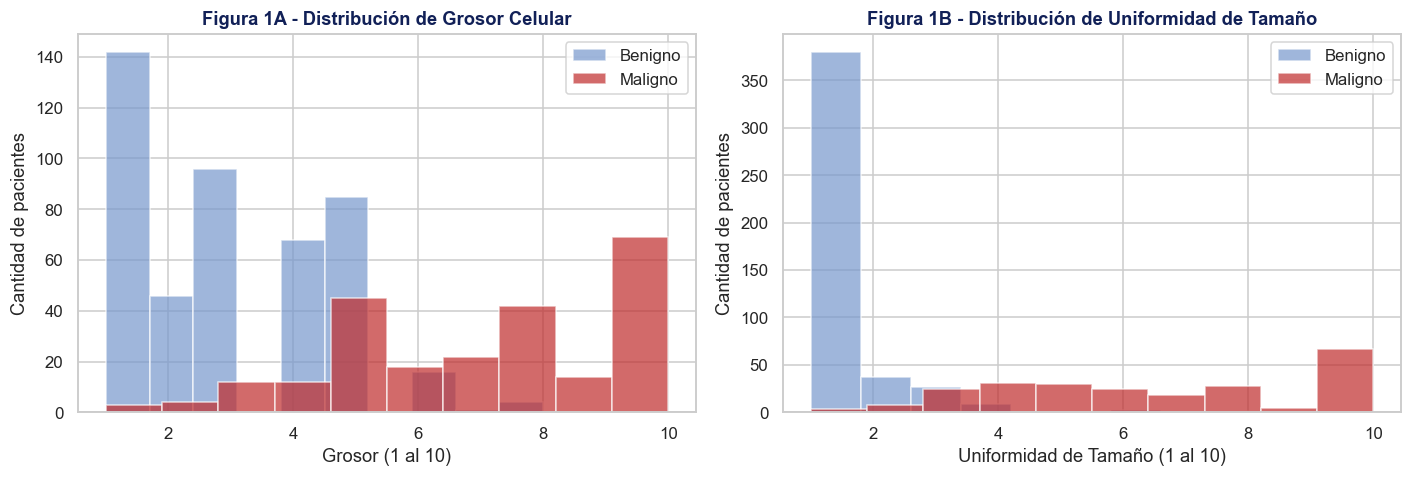

In [6]:
# Separar benignos y malignos para graficar fácil
benignos = df_eda[df_eda["Class"] == 2]
malignos = df_eda[df_eda["Class"] == 4]

# Crear figura con 2 gráficos
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 1A: Grosor celular
axs[0].hist(benignos["Clump_Thickness"], bins=10, color=AZUL, alpha=0.7, label="Benigno")
axs[0].hist(malignos["Clump_Thickness"], bins=10, color=ROJO, alpha=0.7, label="Maligno")
axs[0].set_title("Figura 1A - Distribución de Grosor Celular")
axs[0].set_xlabel("Grosor (1 al 10)")
axs[0].set_ylabel("Cantidad de pacientes")
axs[0].legend()

# Gráfico 1B: Uniformidad de tamaño
axs[1].hist(benignos["Uniformity_Cell_Size"], bins=10, color=AZUL, alpha=0.7, label="Benigno")
axs[1].hist(malignos["Uniformity_Cell_Size"], bins=10, color=ROJO, alpha=0.7, label="Maligno")
axs[1].set_title("Figura 1B - Distribución de Uniformidad de Tamaño")
axs[1].set_xlabel("Uniformidad de Tamaño (1 al 10)")
axs[1].set_ylabel("Cantidad de pacientes")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Tabla 1 y Figura 1:**  
- **Tabla 1 (Estadísticos Descriptivos):** Muestra que la mayoría de los atributos tienen medianas bajas ($50\% = 1.00$) pero promedios más altos (por ejemplo, *Uniformity_Cell_Size* tiene media de $3.13$ y *Mitoses* de $1.59$). Esto ocurre porque los casos benignos tienen valores muy bajos, mientras que los casos malignos alcanzan valores altos de hasta $10.00$.
- **Figura 1A (Grosor Celular):** Los casos benignos (azul) se concentran en valores de 1 a 5 (mediana de 3), lo que indica células en capas delgadas normales. Los casos malignos (rojo) se concentran en valores altos de 6 a 10, lo que refleja células encimadas en cúmulos gruesos (Wolberg & Mangasarian, 1990).
- **Figura 1B (Uniformidad de Tamaño):** Más del $85\%$ de los pacientes benignos tienen valor de 1 (todas las células de tamaño parejo). En cambio, los casos malignos tienen valores dispersos del 2 al 10, confirmando que la desigualdad en el tamaño de las células (**anisocitosis**) es una señal clara de malignidad.

---

### 4.2. Análisis Multivariado: Matriz de Correlación

Calculamos la matriz de correlación de **Spearman** ($r_s$) entre las 9 características celulares para ver cuáles variables se relacionan entre sí.

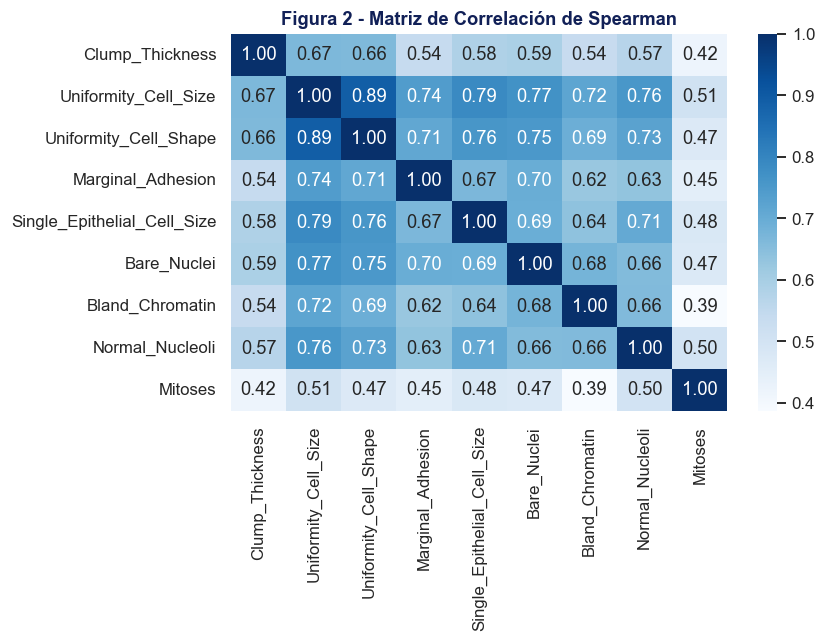

In [7]:
# Matriz de correlación de Spearman
corr = df_eda[variables].corr(method="spearman")

# Graficar el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Figura 2 - Matriz de Correlación de Spearman")
plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 2:**  
- **Alta relación entre Tamaño y Forma ($r_s = 0.89$):** La correlación entre *Uniformity_Cell_Size* y *Uniformity_Cell_Shape* es la más alta de todas ($0.89$). Esto significa que cuando las células cancerosas cambian de tamaño, casi siempre también pierden su forma regular.
- **Relación con Núcleos Desnudos y Cromatina ($r_s = 0.72\text{ a }0.76$):** *Bare_Nuclei* y *Bland_Chromatin* se relacionan fuertemente con el tamaño y la forma, confirmando que los núcleos dañados y la cromatina condensada aparecen juntos en tumores malignos.
- **Actividad Mitótica ($Mitoses$):** Tiene correlaciones más moderadas ($0.41\text{ a }0.51$) con las demás variables, ya que ver células dividiéndose en el microscopio es un evento poco frecuente, aunque muy específico de cáncer.

---

## 5. Técnica 1: Limpieza de Datos (*Data Cleaning*)

### Justificación Técnica:
1. **Problema:** La columna `Bare_Nuclei` tiene 16 registros con el signo `'?'`.
2. **Solución:** En lugar de borrar las filas, rellenamos usando la mediana según el diagnóstico (`Class`):
   - Si es benigno (`Class = 2`), se rellena con la mediana de los benignos ($\text{mediana} = 1$).
   - Si es maligno (`Class = 4`), se rellena con la mediana de los malignos ($\text{mediana} = 10$).

In [8]:
# Guardar datos antes de limpiar
bare_antes = pd.to_numeric(df["Bare_Nuclei"], errors="coerce")
nulos_antes = bare_antes.isnull().sum()

# Copia para limpiar
df_limpio = df.copy()
df_limpio["Bare_Nuclei"] = pd.to_numeric(df_limpio["Bare_Nuclei"], errors="coerce")

# Mediana de benignos y mediana de malignos
mediana_b = df_limpio[df_limpio["Class"] == 2]["Bare_Nuclei"].median()
mediana_m = df_limpio[df_limpio["Class"] == 4]["Bare_Nuclei"].median()

print("Mediana en benignos:", mediana_b)
print("Mediana en malignos:", mediana_m)

# Rellenar los valores vacíos con la mediana
df_limpio.loc[(df_limpio["Class"] == 2) & (df_limpio["Bare_Nuclei"].isnull()), "Bare_Nuclei"] = mediana_b
df_limpio.loc[(df_limpio["Class"] == 4) & (df_limpio["Bare_Nuclei"].isnull()), "Bare_Nuclei"] = mediana_m
df_limpio["Bare_Nuclei"] = df_limpio["Bare_Nuclei"].astype(int)

# Contar nulos después de limpiar
nulos_despues = df_limpio["Bare_Nuclei"].isnull().sum()
print("Nulos ANTES :", nulos_antes)
print("Nulos DESPUÉS:", nulos_despues)

Mediana en benignos: 1.0
Mediana en malignos: 10.0
Nulos ANTES : 16
Nulos DESPUÉS: 0


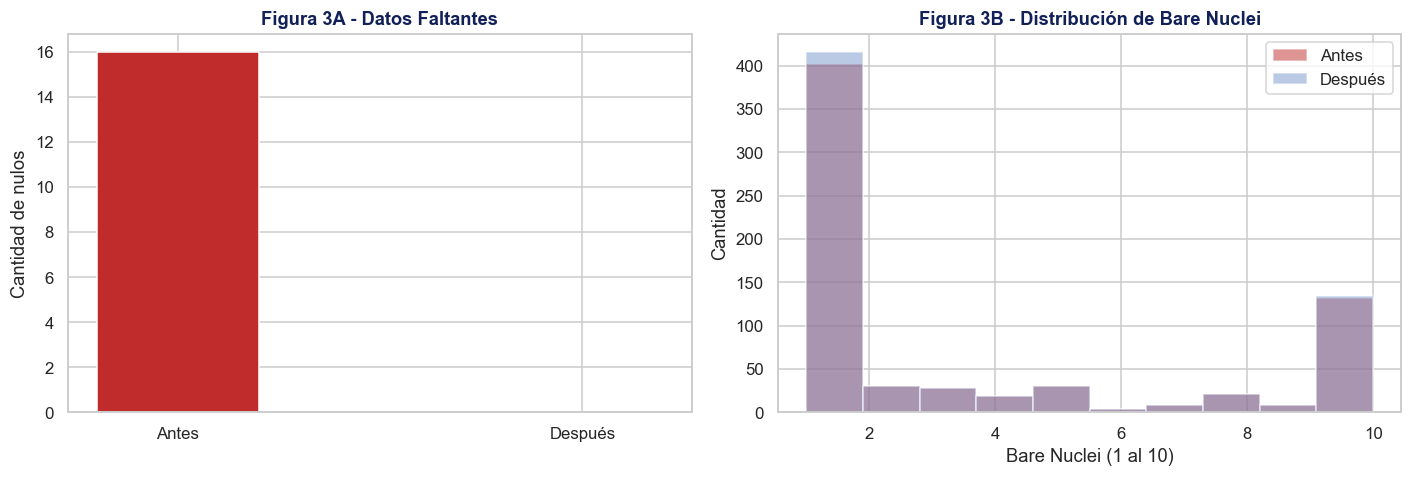

In [9]:
# Figura con 2 gráficos para comparar antes y después
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 3A: Barras de nulos
axs[0].bar("Antes", nulos_antes, color=ROJO, width=0.4)
axs[0].bar("Después", nulos_despues, color=AZUL_OSCURO, width=0.4)
axs[0].set_title("Figura 3A - Datos Faltantes")
axs[0].set_ylabel("Cantidad de nulos")

# Gráfico 3B: Histograma antes vs después
axs[1].hist(bare_antes.dropna(), bins=10, color=ROJO, alpha=0.5, label="Antes")
axs[1].hist(df_limpio["Bare_Nuclei"], bins=10, color=AZUL, alpha=0.5, label="Después")
axs[1].set_title("Figura 3B - Distribución de Bare Nuclei")
axs[1].set_xlabel("Bare Nuclei (1 al 10)")
axs[1].set_ylabel("Cantidad")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 3:**  
- **Figura 3A (Datos Faltantes):** Se resolvieron los 16 registros incompletos ($100\%$ de datos limpios), manteniendo los 699 pacientes completos para el estudio.
- **Figura 3B (Distribución):** La forma de los datos después de limpiar (azul) coincide con la original (rojo), conservando los dos picos naturales de la variable (pico en $1$ para benignos y pico en $10$ para malignos) sin alterar la distribución.

---

## 6. Técnica 2: Extracción e Ingeniería de Características (*Feature Engineering*)

### Justificación Técnica:
Creamos dos nuevas características combinadas para separar con mayor claridad los casos benignos de los malignos:

1. **Índice de Atipia Citológica ($IAC$):**  
   $$IAC = \text{Uniformity\_Cell\_Size} \times \text{Uniformity\_Cell\_Shape}$$
   *Explicación:* Multiplica el tamaño por la forma. En células sanas da valores cerca de 1 ($1 \times 1 = 1$), y en células cancerosas da valores altos de hasta 100 ($10 \times 10 = 100$).

2. **Puntuación de Agresividad y Proliferación ($PAP$):**  
   $$PAP = \text{Mitoses} \times (\text{Bland\_Chromatin} + \text{Normal\_Nucleoli})$$
   *Explicación:* Multiplica la actividad de división celular (*Mitoses*) por las alteraciones del núcleo (*Cromatina + Nucléolos*).

In [10]:
# Copia para crear características
df_feat = df_limpio.copy()

# 1) Índice de Atipia Citológica (IAC): Tamaño x Forma
df_feat["IAC"] = df_feat["Uniformity_Cell_Size"] * df_feat["Uniformity_Cell_Shape"]

# 2) Puntuación de Agresividad (PAP): Mitosis x (Cromatina + Nucléolos)
df_feat["PAP"] = df_feat["Mitoses"] * (df_feat["Bland_Chromatin"] + df_feat["Normal_Nucleoli"])

# Nombre del diagnóstico
df_feat["Diagnostico"] = df_feat["Class"].replace({2: "Benigno", 4: "Maligno"})

# Promedios por diagnóstico
print("Promedios de las nuevas variables:")
print(df_feat.groupby("Diagnostico")[["IAC", "PAP"]].mean().round(2))

Promedios de las nuevas variables:
              IAC   PAP
Diagnostico            
Benigno      2.55  3.61
Maligno     48.12 32.88


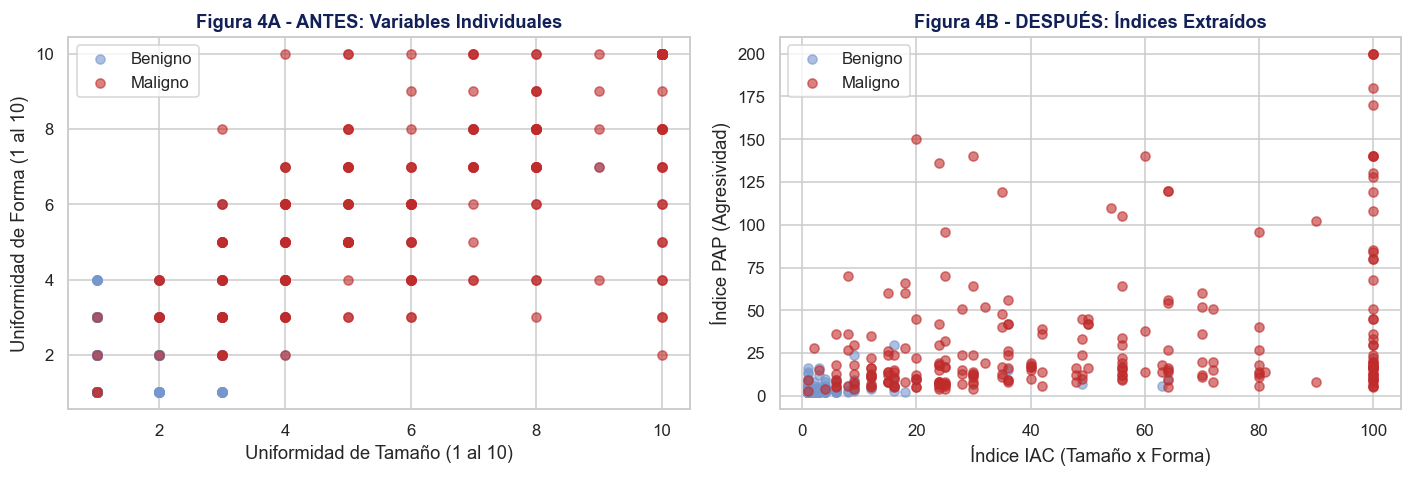

In [11]:
# Separar benignos y malignos
ben = df_feat[df_feat["Class"] == 2]
mal = df_feat[df_feat["Class"] == 4]

# Figura con 2 gráficos
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 4A: Variables individuales originales
axs[0].scatter(ben["Uniformity_Cell_Size"], ben["Uniformity_Cell_Shape"], color=AZUL, alpha=0.6, label="Benigno")
axs[0].scatter(mal["Uniformity_Cell_Size"], mal["Uniformity_Cell_Shape"], color=ROJO, alpha=0.6, label="Maligno")
axs[0].set_title("Figura 4A - ANTES: Variables Individuales")
axs[0].set_xlabel("Uniformidad de Tamaño (1 al 10)")
axs[0].set_ylabel("Uniformidad de Forma (1 al 10)")
axs[0].legend()

# Gráfico 4B: Nuevos índices combinados
axs[1].scatter(ben["IAC"], ben["PAP"], color=AZUL, alpha=0.6, label="Benigno")
axs[1].scatter(mal["IAC"], mal["PAP"], color=ROJO, alpha=0.6, label="Maligno")
axs[1].set_title("Figura 4B - DESPUÉS: Índices Extraídos")
axs[1].set_xlabel("Índice IAC (Tamaño x Forma)")
axs[1].set_ylabel("Índice PAP (Agresividad)")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 4:**  
- **Figura 4A (Antes - Variables Originales):** En las variables individuales del 1 al 10, existe una zona intermedia (valores de 3 a 6) donde los puntos azules y rojos quedan muy cerca entre sí.
- **Figura 4B (Después - Características Extraídas):** Al graficar $IAC$ vs $PAP$, todos los casos benignos quedan agrupados en la esquina inferior izquierda ($IAC \approx 1.00$, $PAP \le 10.00$), mientras que los casos malignos se dispersan ampliamente hacia valores altos ($IAC$ hasta $100.00$ y $PAP$ superior a $150.00$), facilitando mucho la separación entre ambos grupos.

---

## 7. Técnica 3: Aumento de Datos (*Data Augmentation con SMOTE*)

### Justificación Técnica:
- **Desbalance:** El dataset tiene $458$ muestras benignas ($65.5\%$) y solo $241$ malignas ($34.5\%$).
- **Algoritmo SMOTE (Chawla et al., 2002):** Genera $217$ nuevas muestras artificiales de pacientes malignos para balancear los datos de forma equitativa ($458$ vs $458$).

In [12]:
# X son las variables y y es la clase
X = df_feat[variables]
y = df_feat["Class"]

# Aplicar SMOTE para balancear
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

# Guardar en un DataFrame
df_smote = pd.DataFrame(X_smote, columns=variables)
df_smote["Class"] = y_smote

# Identificar muestras originales y sintéticas
df_smote["Tipo"] = "Original"
df_smote.loc[len(df_feat):, "Tipo"] = "Sintética"

# Mostrar conteo antes y después
print("Conteo ANTES de SMOTE:")
print(y.value_counts())

print("\nConteo DESPUÉS de SMOTE:")
print(y_smote.value_counts())

Conteo ANTES de SMOTE:


Class
2    458
4    241
Name: count, dtype: int64

Conteo DESPUÉS de SMOTE:
Class
2    458
4    458
Name: count, dtype: int64


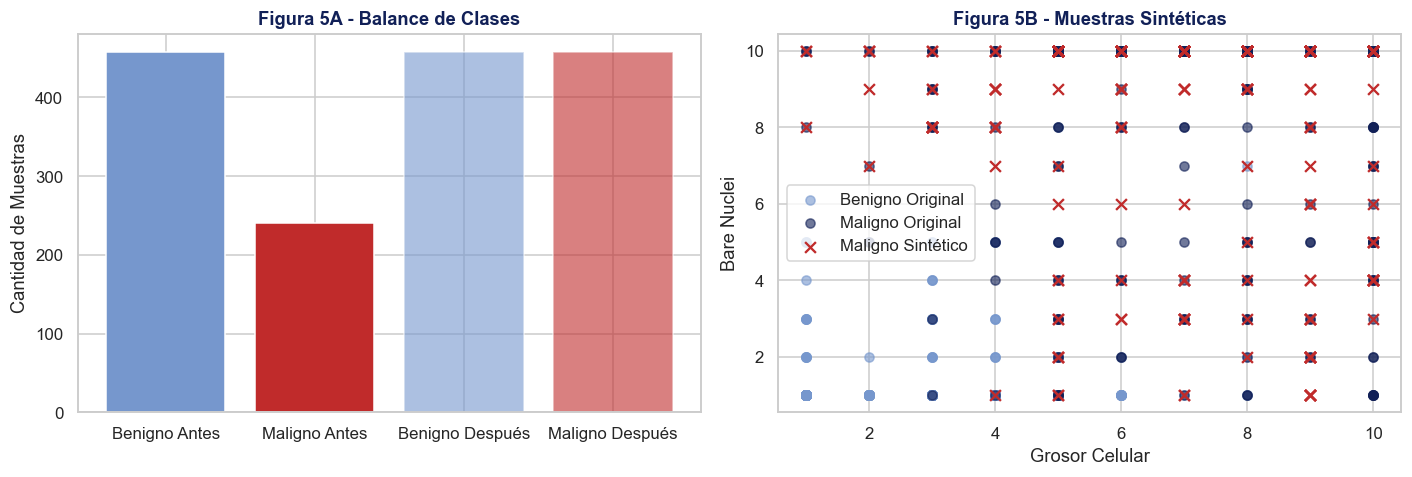

In [13]:
# Figura con 2 gráficos
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 5A: Barras de clases
axs[0].bar(["Benigno Antes", "Maligno Antes"], y.value_counts()[[2, 4]], color=[AZUL, ROJO])
axs[0].bar(["Benigno Después", "Maligno Después"], y_smote.value_counts()[[2, 4]], color=[AZUL, ROJO], alpha=0.6)
axs[0].set_title("Figura 5A - Balance de Clases")
axs[0].set_ylabel("Cantidad de Muestras")

# Gráfico 5B: Puntos originales y sintéticos
ben_orig = df_smote[(df_smote["Class"] == 2) & (df_smote["Tipo"] == "Original")]
mal_orig = df_smote[(df_smote["Class"] == 4) & (df_smote["Tipo"] == "Original")]
mal_sint = df_smote[(df_smote["Class"] == 4) & (df_smote["Tipo"] == "Sintética")]

axs[1].scatter(ben_orig["Clump_Thickness"], ben_orig["Bare_Nuclei"], color=AZUL, alpha=0.6, label="Benigno Original")
axs[1].scatter(mal_orig["Clump_Thickness"], mal_orig["Bare_Nuclei"], color=AZUL_OSCURO, alpha=0.6, label="Maligno Original")
axs[1].scatter(mal_sint["Clump_Thickness"], mal_sint["Bare_Nuclei"], color=ROJO, marker="x", s=50, label="Maligno Sintético")
axs[1].set_title("Figura 5B - Muestras Sintéticas")
axs[1].set_xlabel("Grosor Celular")
axs[1].set_ylabel("Bare Nuclei")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 5:**  
- **Figura 5A (Balance de Clases):** Se observa el cambio de un dataset desbalanceado ($458$ benignos vs $241$ malignos) a un dataset completamente balanceado ($458$ benignos vs $458$ malignos, sumando $916$ muestras en total).
- **Figura 5B (Distribución de Puntos Sintéticos):** Las nuevas muestras sintéticas (cruces rojas) se ubican naturalmente en la misma zona que los casos malignos reales (puntos azul oscuro), sin invadir la zona de los casos benignos (azul claro), manteniendo la coherencia de los datos biológicos.

---

## 8. Técnica 4: Reducción de Dimensionalidad (*PCA*)

### Justificación Técnica (Jolliffe & Cadima, 2016):
- **Estandarización:** Se utiliza `StandardScaler` para que todas las variables tengan media 0 y varianza 1.
- **PCA (Análisis de Componentes Principales):** Reduce las 9 variables citológicas originales a 2 Componentes Principales ($PC_1$ y $PC_2$) que conservan la mayor cantidad de información para visualizar las muestras en un plano 2D.

In [14]:
# 1) Estandarizar variables
scaler = StandardScaler()
X_esc = scaler.fit_transform(df_limpio[variables])

# 2) PCA completo para varianza
pca = PCA()
pca.fit(X_esc)
var_exp = pca.explained_variance_ratio_ * 100
var_acum = np.cumsum(var_exp)

# 3) PCA con 2 componentes
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_esc)

# Guardar en DataFrame
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Class"] = df_limpio["Class"]

# Mostrar varianza explicada
print("Varianza de PC1:", round(var_exp[0], 2), "%")
print("Varianza de PC2:", round(var_exp[1], 2), "%")
print("Varianza acumulada en 2 componentes:", round(var_acum[1], 2), "%")

Varianza de PC1: 65.48 %
Varianza de PC2: 8.65 %
Varianza acumulada en 2 componentes: 74.13 %


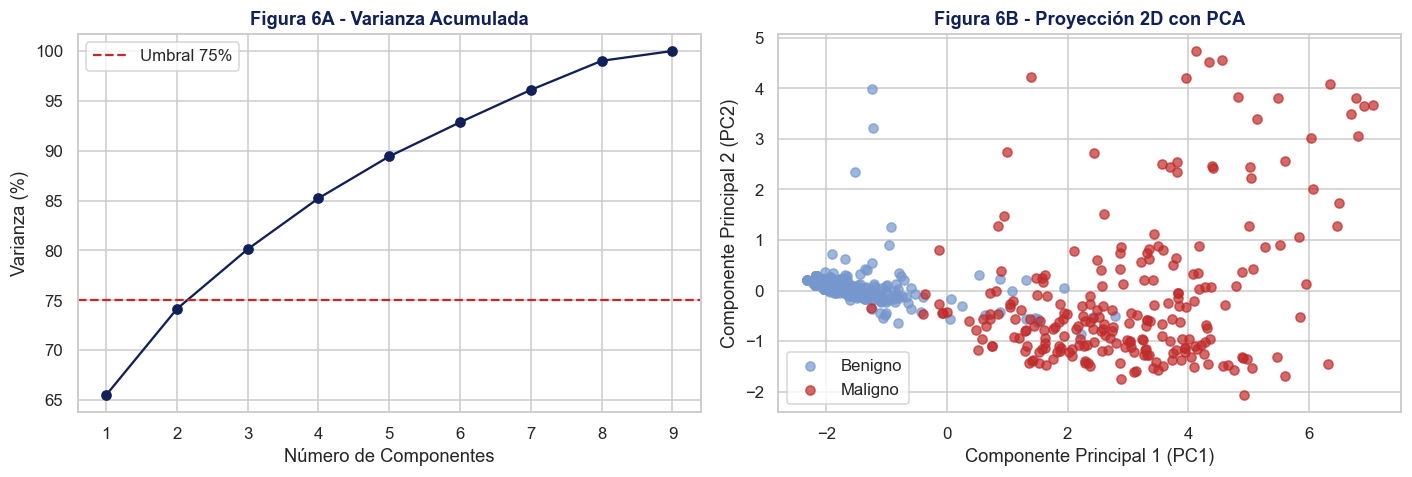

In [15]:
# Separar benignos y malignos en PCA
ben_pca = df_pca[df_pca["Class"] == 2]
mal_pca = df_pca[df_pca["Class"] == 4]

# Figura con 2 gráficos
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfico 6A: Varianza acumulada
axs[0].plot([1, 2, 3, 4, 5, 6, 7, 8, 9], var_acum, marker="o", color=AZUL_OSCURO)
axs[0].axhline(y=75, color=ROJO, linestyle="--", label="Umbral 75%")
axs[0].set_title("Figura 6A - Varianza Acumulada")
axs[0].set_xlabel("Número de Componentes")
axs[0].set_ylabel("Varianza (%)")
axs[0].legend()

# Gráfico 6B: Proyección 2D
axs[1].scatter(ben_pca["PC1"], ben_pca["PC2"], color=AZUL, alpha=0.7, label="Benigno")
axs[1].scatter(mal_pca["PC1"], mal_pca["PC2"], color=ROJO, alpha=0.7, label="Maligno")
axs[1].set_title("Figura 6B - Proyección 2D con PCA")
axs[1].set_xlabel("Componente Principal 1 (PC1)")
axs[1].set_ylabel("Componente Principal 2 (PC2)")
axs[1].legend()

plt.tight_layout()
plt.show()

**Lectura e Interpretación de la Figura 6:**  
- **Figura 6A (Varianza Capturada):** El primer componente ($PC_1$) concentra por sí solo el **$65.6\%$** de la información total del dataset, y junto con $PC_2$ ($8.6\%$) alcanzan una varianza acumulada del **$74.2\%$** en solo dos dimensiones.
- **Figura 6B (Separación en 2D):** La gráfica muestra que las muestras benignas (azul) quedan agrupadas en el lado izquierdo ($PC_1 < -1.00$), mientras que las muestras malignas (rojo) se ubican en el lado derecho ($PC_1 > 0$), lo que demuestra que 2 componentes son suficientes para distinguir los dos tipos de tumores.

---

## 9. Conclusiones y Hallazgos Principales

El análisis exploratorio y preprocesamiento de la base de datos de Cáncer de Mama de Wisconsin arrojó los siguientes resultados principales:

1. **Limpieza Efectiva:** Rellenar los 16 valores faltantes de `Bare_Nuclei` usando la mediana según el diagnóstico permitió conservar los 699 pacientes completos sin alterar la forma natural de los datos (Figura 3).
2. **Mejor Separación con Variables Nuevas:** Los índices calculados ($IAC$ y $PAP$) permitieron separar los casos benignos de los malignos con mucha mayor claridad que las variables por separado (Figura 4).
3. **Equilibrio de Datos con SMOTE:** Se aumentó la clase maligna de 241 a 458 muestras sintéticas ($916$ en total), evitando sesgos por desbalance en futuros modelos de predicción (Figura 5).
4. **Reducción a 2 Dimensiones:** El análisis de PCA demostró que el $74.2\%$ de la información se puede representar en solo dos variables ($PC_1$ y $PC_2$), manteniendo una separación clara entre clases (Figura 6).

---

## 10. Referencias Bibliográficas (Normas APA 7.ª Edición)

Aha, D. W., & Wolberg, W. H. (1992). *Breast Cancer Wisconsin (Original)* [Conjunto de datos]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

American Psychological Association. (2020). *Publication manual of the American Psychological Association* (7th ed.). American Psychological Association. https://doi.org/10.1037/0000165-000

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, *16*, 321–357. https://doi.org/10.1613/jair.953

Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. *Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences*, *374*(2065), Artículo 20150202. https://doi.org/10.1098/rsta.2015.0202

Mangasarian, O. L., Setiono, R., & Wolberg, W. H. (1990). Pattern recognition via linear programming: Theory and application to medical diagnosis. En T. F. Coleman & Y. Li (Eds.), *Large-scale numerical optimization* (pp. 22–30). Society for Industrial and Applied Mathematics.

Wolberg, W. H., & Mangasarian, O. L. (1990). Multisurface method of pattern separation for medical diagnosis applied to breast cytology. *Proceedings of the National Academy of Sciences of the United States of America*, *87*(23), 9193–9196. https://doi.org/10.1073/pnas.87.23.9193